В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [91]:
!pip install scikit-learn --quiet

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error

In [24]:
medical_df = pd.read_csv('../../Sample Data/medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [81]:
X = non_smoker_df[['age']]
y = non_smoker_df['charges']

**MNK**

In [53]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [82]:
MNK_coefs = normal_equations(X, y)
MNK_coefs

array([220.16239904])

In [56]:
np.dot(X.iloc[0].values, MNK_coefs)

3962.9231827820768

In [83]:
predictions_MNK = np.dot(X, MNK_coefs)

In [63]:
rmse = np.sqrt(mean_squared_error(y, predictions_MNK))
rmse

4715.339046259168

**Full-Batch**

In [ ]:
# Градієнтний спуск (Full-Batch)
def full_batch_gradient_descent(X, y, lr=1e-5, epochs=5000):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(np.mean(error**2))
        m_gradient = (2 / n) * np.dot(error, X[:, 0])
        b_gradient = (2 / n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, np.array(errors)

X_np = X.to_numpy()
y_np = y.to_numpy()

learning_rates = [1e-5, 5e-5, 1e-4]
gd_results = {}

for lr in learning_rates:
    m_lr, b_lr, errors_lr = full_batch_gradient_descent(X_np, y_np, lr=lr, epochs=5000)
    preds_lr = b_lr + m_lr * X_np[:, 0]
    rmse_lr = np.sqrt(mean_squared_error(y_np, preds_lr))
    gd_results[lr] = {
        'm': m_lr,
        'b': b_lr,
        'losses': errors_lr,
        'final_loss': errors_lr[-1] if len(errors_lr) > 0 else np.inf,
        'rmse': rmse_lr,
        'predictions': preds_lr
    }

best_lr = min(gd_results, key=lambda lr: gd_results[lr]['final_loss'])
m = gd_results[best_lr]['m']
b = gd_results[best_lr]['b']
errors = gd_results[best_lr]['losses']
predictions_fbgd = gd_results[best_lr]['predictions']
predictions_sgd = predictions_fbgd

Full-Batch GD by learning rate:
lr=1e-05: intercept=-18.6460, slope=220.5792, RMSE=4714.41
lr=5e-05: intercept=-110.4213, slope=222.6456, RMSE=4709.93
lr=0.0001: intercept=-219.4486, slope=225.1004, RMSE=4704.88
Best learning rate by final loss: 0.0001


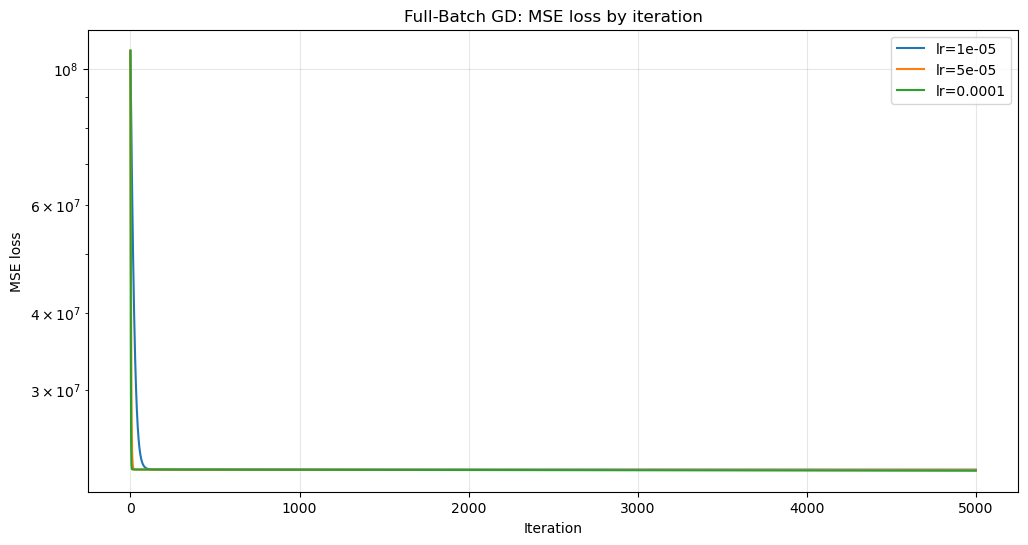

In [113]:
print('Full-Batch GD by learning rate:')
for lr, result in gd_results.items():
    print(f"lr={lr}: intercept={result['b']:.4f}, slope={result['m']:.4f}, RMSE={result['rmse']:.2f}")

print(f'Best learning rate by final loss: {best_lr}')

plt.figure(figsize=(12, 6))
for lr, result in gd_results.items():
    plt.plot(result['losses'], label=f'lr={lr}')

plt.title('Full-Batch GD: MSE loss by iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**LinearRegression**

In [86]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

predictions_sklearn = lin_reg.predict(X)

lin_reg.coef_, lin_reg.intercept_
r2 = lin_reg.score(X, y)
mse = mean_squared_error(y, predictions_sklearn)
rmse = np.sqrt(mse)

print(f'R^2: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')

R^2: 0.3943
RMSE: 4662.51


Для Full-Batch градієнтного спуску протестовано 3 learning rate: 1e-5, 5e-5, 1e-4.

Висновок: 0.1 для цієї задачі завеликий і може призводити до розбіжності, а найкращим серед протестованих нижчих learning rate є той, що дає найменшу фінальну помилку (best_lr у виводі вище).

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [25]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [44]:
X = smoker_df[['age']]
y = smoker_df['charges']

lin_reg = LinearRegression()
lin_reg.fit(X, y)

predictions_sklearn = lin_reg.predict(X)

coef = lin_reg.coef_[0]
intercept = lin_reg.intercept_
r2 = lin_reg.score(X, y)
mse = mean_squared_error(y, predictions_sklearn)
rmse = np.sqrt(mse)

print(f'Coefficient (age): {coef:.4f}')
print(f'Intercept: {intercept:.4f}')
print(f'R^2: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')

Coefficient (age): 305.2376
Intercept: 20294.1281
R^2: 0.1356
RMSE: 10711.00


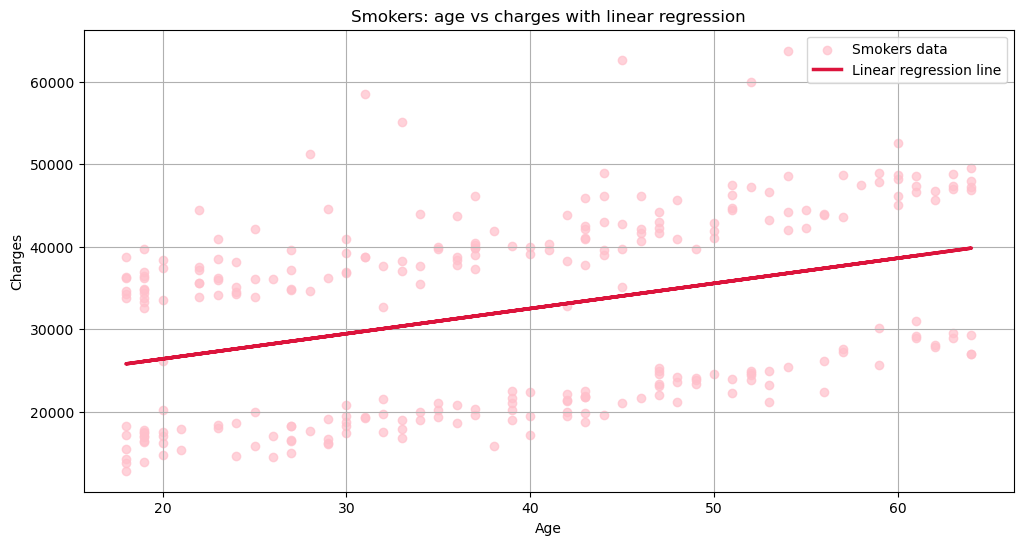

In [34]:
plt.figure(figsize=(12, 6))

plt.scatter(X['age'], y, color='pink', alpha=0.7, label='Smokers data')
plt.plot(X['age'], predictions_sklearn, color='crimson', linewidth=2.5, label='Linear regression line')

plt.title('Smokers: age vs charges with linear regression')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.grid(True)
plt.legend()
plt.show()

Висновки:
1. Модель слабка для практичного використання в компанії у такому вигляді.
Причина: R² ≈ 0.14 означає, що вік пояснює лише невелику частину варіації витрат.
2. RMSE доволі велика, тож похибка прогнозу значна.
3. Для бізнес-використання варто додати інші ознаки (наприклад BMI, children, sex, region)